In [1]:
import torch
import torch.nn.functional as F

#define values
img = torch.rand(16, 3, 64, 64)
kernel_size=32
stride=16

# assert kernel_size==stride, "stride and kernel_size must be equal"

#create mask
mask = torch.ones_like(img)
mask = F.unfold(mask, kernel_size=kernel_size, stride=stride) # batch_size, channels*kernel*kernel, patches
N, chw, p = mask.shape
mask = mask.unsqueeze(3).expand(N, chw, p, p).clone()

diag = torch.diag(torch.ones(p)).bool()
mask[:,:,diag]=0

N, c, h, w = img.shape
mask = mask.reshape(N, c, kernel_size, kernel_size, p, p)
mask = mask.permute(0,4,1,2,3,5).reshape(N*p*c, kernel_size*kernel_size, p)
mask = F.fold(mask, (h,w), kernel_size=kernel_size, stride=stride)
mask = mask.reshape(N,p, c, h, w)

#expand img
masked_img=img.unsqueeze(1).expand(N,p,c,h,w).clone()

#apply mask
masked_img[~mask.bool()] = 0.5
masked_img.shape

torch.Size([16, 9, 3, 64, 64])

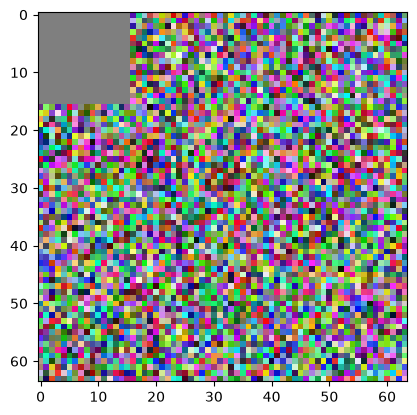

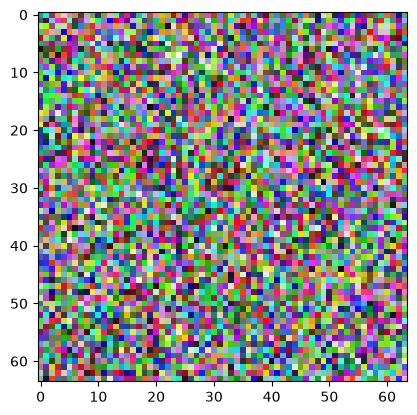

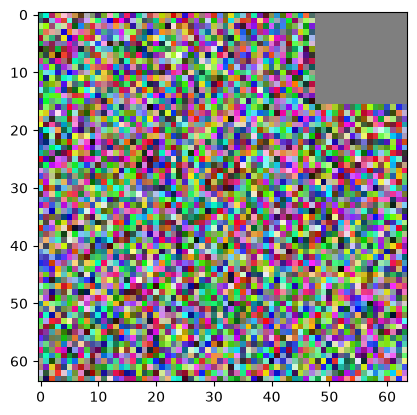

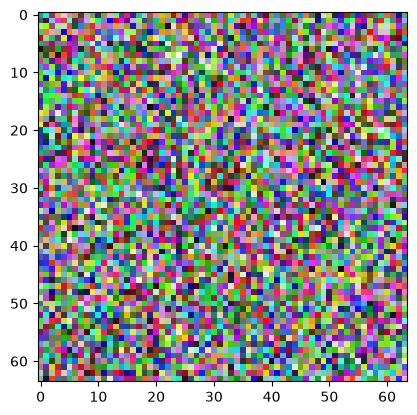

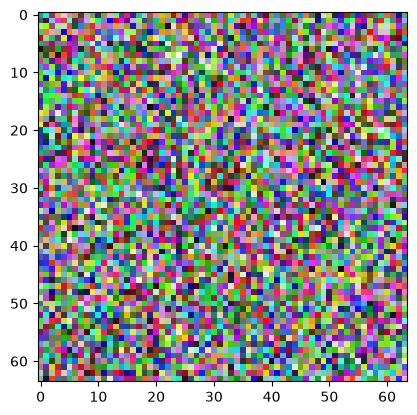

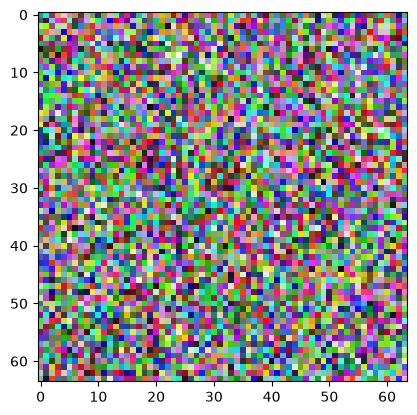

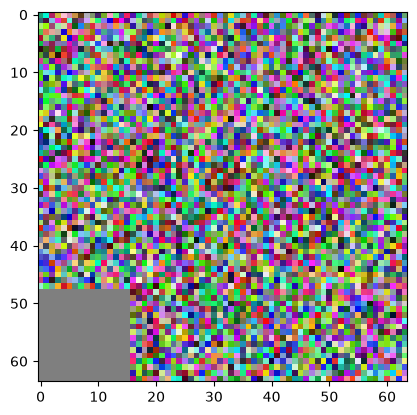

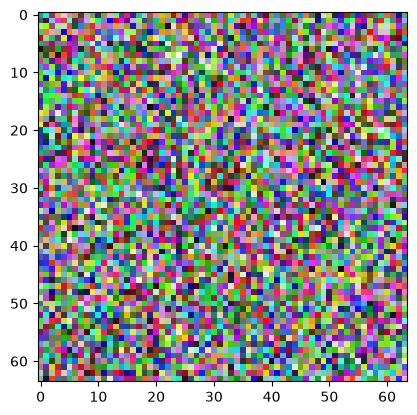

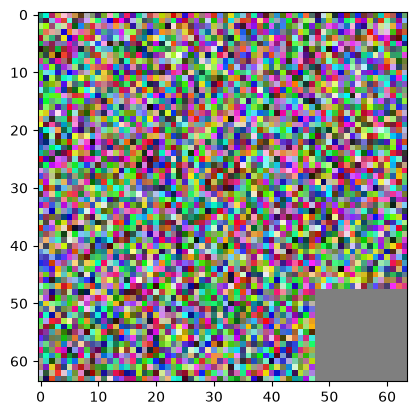

In [2]:
import matplotlib.pyplot as plt

for i in range(9):
    img_i = masked_img[0, i, ...]
    plt.imshow(img_i.movedim(0, -1))
    plt.show()

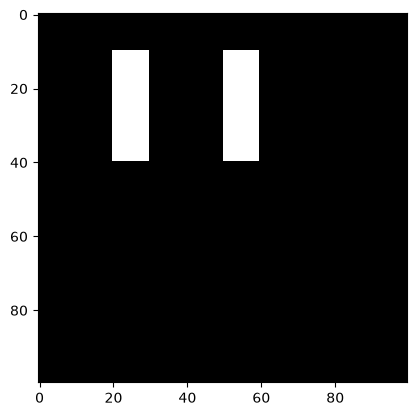

In [3]:
import matplotlib.pyplot as plt
import numpy as np

mask = np.zeros((100, 100, 1), dtype=float)
mask[10:40, 20:30, :] = 1
mask[10:40, 50:60, :] = 1
plt.imshow(mask, cmap="gray")
plt.show()

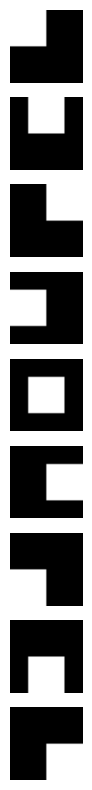

In [4]:
import matplotlib.pyplot as plt

from occlusions import generate_occlusion_masks

masks = generate_occlusion_masks((32, 32), (16, 16), (8, 8))
fig, axes = plt.subplots(masks.shape[0], figsize=(10, 10))
for mask, ax in zip(masks, axes):
    ax.imshow(mask, cmap="gray")
    ax.set_axis_off()

plt.show()

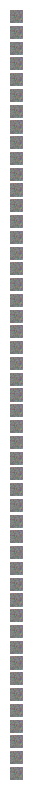

In [9]:
from occlusions import generate_occluded_batch

batch = generate_occluded_batch(img[0], (16, 16), (8, 8), baseline=0.5)
fig, axes = plt.subplots(batch.shape[0], figsize=(10, 10))
for image, ax in zip(batch, axes):
    ax.imshow(image.movedim(0, -1))
    ax.set_axis_off()

plt.show()

In [ ]:
from occlusions import ImageOcclusion

attributer = ImageOcclusion()
attributer.